In [3]:
import cv2
import matplotlib.pyplot as plt

# Load passport photo
photo = cv2.imread("photo.jpeg")

# Load sunglasses with transparency
glasses = cv2.imread("sunglass.jpg", cv2.IMREAD_UNCHANGED)

print("Photo shape:", photo.shape)
print("Glasses shape:", glasses.shape)

Photo shape: (1426, 1103, 3)
Glasses shape: (859, 840, 3)


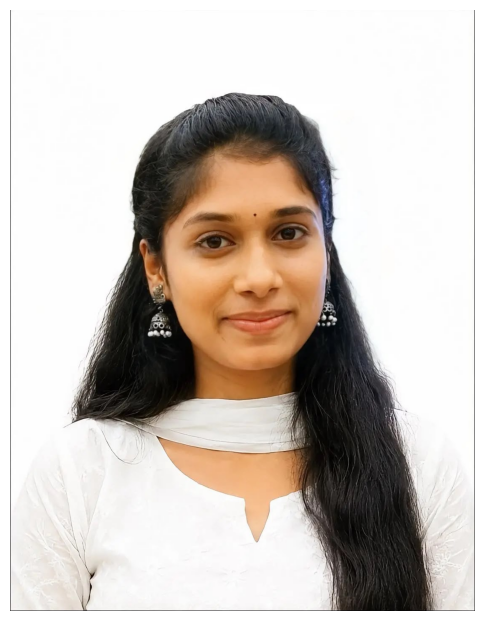

In [4]:
plt.figure(figsize=(6, 8))

plt.imshow(cv2.cvtColor(photo, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

In [5]:
glasses_crop = glasses[260:600, :]

In [6]:
hsv = cv2.cvtColor(glasses_crop, cv2.COLOR_BGR2HSV)

mask = cv2.inRange(
    hsv,
    np.array([0, 25, 40]),
    np.array([179, 255, 255])
)

In [7]:
kernel = np.ones((3, 3), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

In [8]:
points = cv2.findNonZero(mask)

x, y, w, h = cv2.boundingRect(points)

glasses_crop = glasses_crop[y:y+h, x:x+w]
mask = mask[y:y+h, x:x+w]


In [9]:
new_width = 430
new_height = int(h * new_width / w)

glasses_resized = cv2.resize(
    glasses_crop,
    (new_width, new_height)
)

mask_resized = cv2.resize(
    mask,
    (new_width, new_height)
)

In [14]:
x1 = 355
y1 = 455

x2 = x1 + new_width
y2 = y1 + new_height
roi = photo[y1:y2, x1:x2]

In [15]:
alpha = mask_resized.astype(float) / 255.0
alpha = alpha[:, :, np.newaxis]

In [16]:
blended = (
    glasses_resized.astype(float) * alpha
    + roi.astype(float) * (1 - alpha)
)

blended = blended.astype(np.uint8)

# Put blended region back into photo
output = photo.copy()
output[y1:y2, x1:x2] = blended

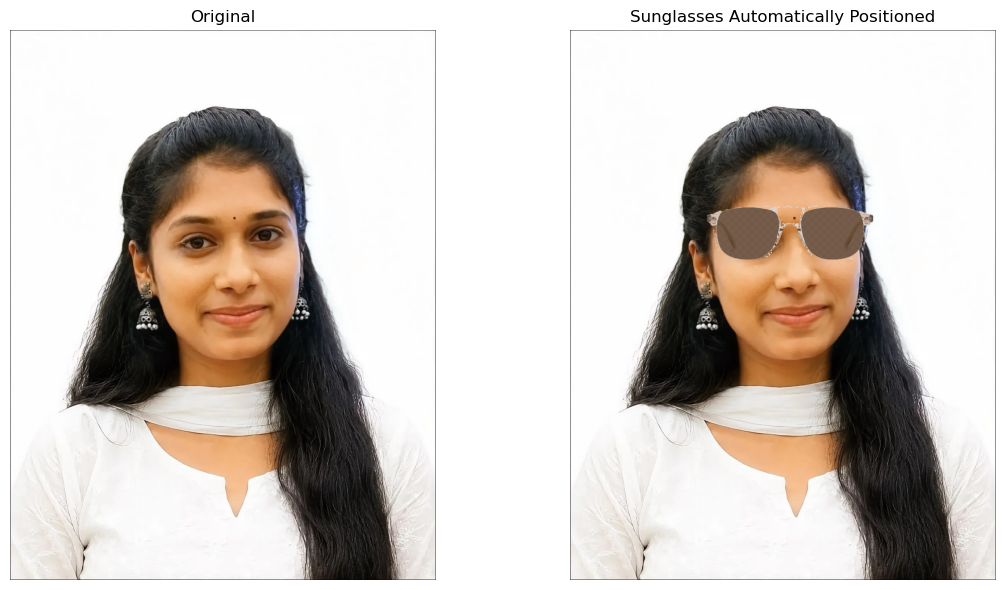

In [18]:

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(photo, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Sunglasses Automatically Positioned")
plt.axis("off")

plt.tight_layout()
plt.show()